In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier,Pool
import lightgbm as lgb

In [2]:
df=sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [4]:
df=df.drop(["alive","alone","embark_town","deck","who","adult_male"],axis=1)

In [5]:
df.isnull().sum()

survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
class         0
dtype: int64

In [6]:
df["age"]=df["age"].fillna(df["age"].median())
df["embarked"]=df["embarked"].fillna(df["embarked"].mode()[0])

In [7]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class
0,0,3,male,22.0,1,0,7.2500,S,Third
1,1,1,female,38.0,1,0,71.2833,C,First
2,1,3,female,26.0,0,0,7.9250,S,Third
3,1,1,female,35.0,1,0,53.1000,S,First
4,0,3,male,35.0,0,0,8.0500,S,Third


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   survived  891 non-null    int64   
 1   pclass    891 non-null    int64   
 2   sex       891 non-null    str     
 3   age       891 non-null    float64 
 4   sibsp     891 non-null    int64   
 5   parch     891 non-null    int64   
 6   fare      891 non-null    float64 
 7   embarked  891 non-null    str     
 8   class     891 non-null    category
dtypes: category(1), float64(2), int64(4), str(2)
memory usage: 61.8 KB


In [20]:
cat_features=["sex","embarked","class"]

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
x=df.drop("survived",axis=1)
y=df["survived"]

In [23]:
x_train,x_val,y_train,y_val=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [24]:
from catboost import CatBoostClassifier

In [57]:
model=CatBoostClassifier(
    iterations=300,
    learning_rate=1,
    verbose=50
)

In [58]:
model.fit(x_train,y_train,
          eval_set=(x_val,y_val),
          use_best_model=True,
          cat_features=cat_features
          
         )

0:	learn: 0.4003632	test: 0.4999732	best: 0.4999732 (0)	total: 26.8ms	remaining: 8.01s
50:	learn: 0.0898650	test: 0.6543292	best: 0.4576648 (5)	total: 1.21s	remaining: 5.9s
100:	learn: 0.0445541	test: 0.7033745	best: 0.4576648 (5)	total: 2.38s	remaining: 4.68s
150:	learn: 0.0288960	test: 0.7152738	best: 0.4576648 (5)	total: 3.92s	remaining: 3.86s
200:	learn: 0.0226963	test: 0.7385591	best: 0.4576648 (5)	total: 5.33s	remaining: 2.63s
250:	learn: 0.0190398	test: 0.7594123	best: 0.4576648 (5)	total: 6.48s	remaining: 1.26s
299:	learn: 0.0163220	test: 0.7802637	best: 0.4576648 (5)	total: 7.75s	remaining: 0us

bestTest = 0.4576647532
bestIteration = 5

Shrink model to first 6 iterations.


CatBoostClassifier(iterations=300, learning_rate=1, verbose=50)

In [59]:
model.score(x_val,y_val)

np.float64(0.8156424581005587)

In [60]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [61]:
pre_cat=model.predict(x_val)

In [62]:
accuracy_score(pre_cat,y_val)

0.8156424581005587

In [63]:
classification_report(pre_cat,y_val)

'              precision    recall  f1-score   support\n\n           0       0.88      0.82      0.85       112\n           1       0.73      0.81      0.77        67\n\n    accuracy                           0.82       179\n   macro avg       0.80      0.81      0.81       179\nweighted avg       0.82      0.82      0.82       179\n'

In [64]:
cm=confusion_matrix(pre_cat,y_val)

<Axes: >

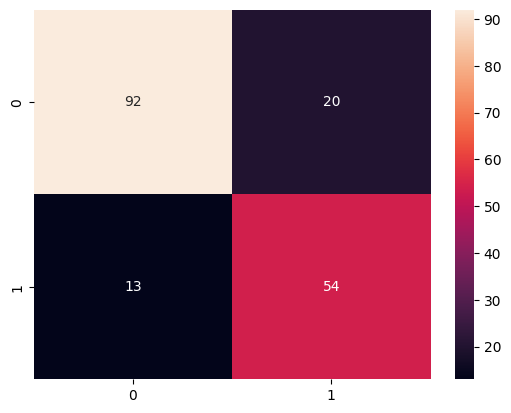

In [65]:
sns.heatmap(cm,annot=True)

In [66]:
model.score(x_train,y_train)

np.float64(0.8525280898876404)